In [1]:
import tensorflow as tf
import numpy as np
import time
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical


I0000 00:00:1778497463.197352    4188 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778497488.495756    4188 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778497505.545757    4188 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
# Check Hardware (CPU / GPU)
device_name = tf.test.gpu_device_name()
if device_name != '':
    print("GPU is available:", device_name)
    device = '/GPU:0'
else:
    print("GPU not available. Running on CPU.")
    device = '/CPU:0'


GPU not available. Running on CPU.


E0000 00:00:1778497519.040248    4188 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
#  Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Reshape (Add channel dimension)
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# One-hot encode labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
# Build CNN Model (4+ Conv Layers)
def create_model():
    model = models.Sequential()

    # Convolution Block 1
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(28,28,1)))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Convolution Block 2
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    # Flatten
    model.add(layers.Flatten())

    # Fully Connected Layers
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    return model


In [5]:
# Train Model and Measure Time
epochs = 10   # You can change this value

with tf.device(device):
    model = create_model()

    start_time = time.time()

    history = model.fit(
        X_train, y_train,
        epochs=epochs,
        batch_size=128,
        validation_data=(X_test, y_test),
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test, y_test)

    end_time = time.time()


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


W0000 00:00:1778497523.920062    4188 cpu_allocator_impl.cc:82] Allocation of 188160000 exceeds 10% of free system memory.


469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 291ms/step - accuracy: 0.7967 - loss: 0.5645 - val_accuracy: 0.8746 - val_loss: 0.3418
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 138s 284ms/step - accuracy: 0.8788 - loss: 0.3386 - val_accuracy: 0.8959 - val_loss: 0.2783
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 291ms/step - accuracy: 0.8974 - loss: 0.2842 - val_accuracy: 0.9040 - val_loss: 0.2600
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 145s 298ms/step - accuracy: 0.9099 - loss: 0.2522 - val_accuracy: 0.9070 - val_loss: 0.2454
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 137s 289ms/step - accuracy: 0.9185 - loss: 0.2248 - val_accuracy: 0.9201 - val_loss: 0.2183
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 288ms/step - accuracy: 0.9249 - loss: 0.2055 - val_accuracy: 0.9222 - val_loss: 0.2121
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 130s 276ms/step - accuracy: 0.9308 - loss: 0.1880 - val_accuracy: 0.9228 - val_loss: 0.2075
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 134s 286ms/step - accuracy: 0.9377 - loss: 0.16

In [6]:
# Results
print("\n==============================")
print("Final Test Accuracy:", accuracy)
print("Total Execution Time (seconds):", end_time - start_time)
print("==============================")



Final Test Accuracy: 0.9302999973297119
Total Execution Time (seconds): 1391.2104232311249


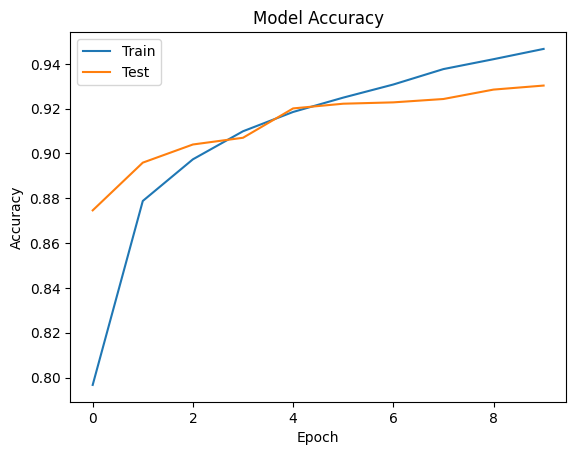

In [7]:
# Plot Accuracy vs Epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Test'])
plt.show()